In [2]:
import cv2
import numpy as np
from IPython.display import display, clear_output, Image
from ugot import ugot

got = ugot.UGOT()
got.initialize("192.168.1.106")
got.load_models(["word_recognition", "face_recognition"])
got.open_camera()

192.168.1.106:50051


Maximum distance (lighting in room 3): 30cm from camera. Text seems more reliable than face.

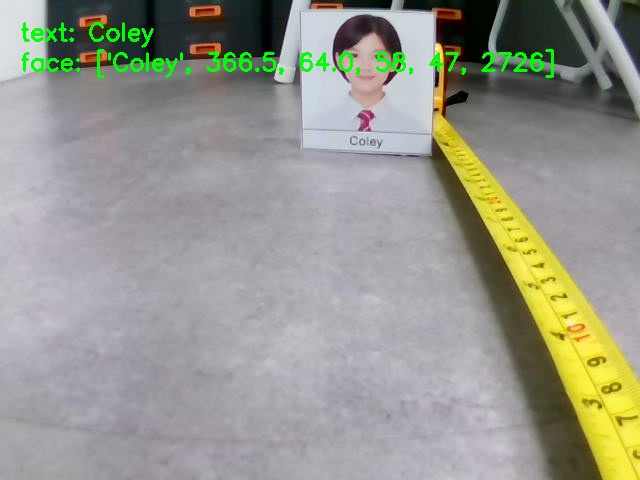

In [11]:
while True:
    try:
        frame = got.read_camera_data()
        nparr = np.frombuffer(frame, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        name = got.get_words_result()
        if name:
            cv2.putText(img, f"text: {name}", (20, 40), 0, 0.8, (0, 255, 0), 2)

        faces = got.get_face_recognition_total_info()
        if faces:
            face = faces[0]
            cv2.putText(img, f"face: {face}", (20, 70), 0, 0.8, (0, 255, 0), 2)
            
        
        _, jpeg = cv2.imencode('.jpg', img)
        clear_output(wait=True)
        display(Image(data=jpeg.tobytes()))

    except KeyboardInterrupt:
        break
